# 03 — Modelagem

Três classificadores distintos, comparados com validação cruzada **agrupada por perfil**:

| Modelo | Por que está aqui |
|---|---|
| Regressão Logística | referência linear, simples e explicável |
| Random Forest | média de muitas árvores; captura interações e relações não lineares |
| Gradient Boosting (`HistGradientBoostingClassifier`) | árvores em sequência, cada uma corrigindo a anterior; costuma ser o mais forte em dados tabulares |

Os três usam `class_weight="balanced"` (só 1,7% de maus pagadores) e ficam dentro de um `Pipeline`
(`src.models.get_models`). Assim o encoder e o scaler são ajustados apenas nos dados de treino de
cada fold.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold, cross_validate

from src.config import CV_FOLDS, DATA_PROCESSED, GROUP, METRICS, MODELS, PROCESSED_FILE, TARGET
from src.data import load_processed
from src.models import get_models
from src.viz import COR_NEUTRA, CORES_MODELOS, aplicar_estilo, salvar

# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
aplicar_estilo()

In [2]:
df = load_processed(PROCESSED_FILE)
selecao = pd.read_csv(METRICS / "selecao_atributos.csv", index_col=0)

finais = selecao.query("decisao == 'manter'")
NUM = finais.query("tipo == 'numerica'").index.tolist()
CAT = finais.query("tipo == 'categorica'").index.tolist()
FEATURES = NUM + CAT
print("Numéricas: ", NUM)
print("Categóricas:", CAT)
df.shape

Numéricas:  ['cadastro_inconsistente', 'idade_anos', 'FLAG_OWN_REALTY', 'anos_empregado', 'AMT_INCOME_TOTAL', 'renda_per_capita']
Categóricas: ['NAME_FAMILY_STATUS', 'OCCUPATION_TYPE', 'NAME_HOUSING_TYPE']


(36457, 21)

## 1. Split treino/teste

O template sugere `train_test_split(..., stratify=y)`. Aqui ele não basta: 73% das linhas repetem
o perfil de outra, e um split linha a linha colocaria cópias do mesmo cliente no treino e no teste.

Usamos `StratifiedGroupKFold` com 5 partes e separamos **uma delas (20%) como teste**. Isso garante:

- **agrupamento:** cada `perfil_id` fica inteiro de um lado só;
- **estratificação:** a proporção de maus pagadores fica próxima nos dois conjuntos;
- **reprodutibilidade:** `shuffle=True` com `random_state=42`.

O teste fica **guardado até o notebook 04**. Toda escolha de modelo acontece só no treino.

In [3]:
y = df[TARGET]
grupos = df[GROUP]

divisor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
idx_treino, idx_teste = next(divisor.split(df, y, grupos))
treino, teste = df.iloc[idx_treino], df.iloc[idx_teste]

X_train, y_train, g_train = treino[FEATURES], treino[TARGET], treino[GROUP]

pd.DataFrame({
    "linhas": [len(treino), len(teste)],
    "% do total": [len(treino) / len(df) * 100, len(teste) / len(df) * 100],
    "maus pagadores": [treino[TARGET].sum(), teste[TARGET].sum()],
    "% maus": [treino[TARGET].mean() * 100, teste[TARGET].mean() * 100],
    "perfis": [treino[GROUP].nunique(), teste[GROUP].nunique()],
}, index=["treino", "teste"]).round(2)

,linhas,% do total,maus pagadores,% maus,perfis
treino,29103,79.83,490,1.68,7667
teste,7354,20.17,126,1.71,1912


In [4]:
print("Perfis presentes nos dois conjuntos:", len(set(treino[GROUP]) & set(teste[GROUP])))

Perfis presentes nos dois conjuntos: 0


**Leitura:**

- **Treino:** 29.103 linhas (79,8%). **Teste:** 7.354 linhas (20,2%).
- A taxa de maus pagadores ficou praticamente igual nos dois conjuntos (1,68% e 1,71%), o que
  mostra que a estratificação funcionou.
- **Nenhum perfil aparece nos dois conjuntos.** O teste simula clientes realmente novos.
- Dos 17 cadastros inconsistentes, 14 ficaram no treino e 3 no teste.

## 2. Modelos candidatos e validação cruzada

Validação cruzada com 5 folds **agrupados e estratificados** sobre o treino. Para cada fold
registramos:

- **PR-AUC** (*average precision*): a **métrica principal**. Mede a qualidade da ordenação de
  risco quando a classe positiva é rara. Um modelo sem informação alguma tem PR-AUC igual à
  proporção de maus (~0,017).
- **AUC-ROC**: probabilidade de o modelo dar risco maior a um mau pagador do que a um bom
  sorteados ao acaso. Vale 0,5 se o modelo chuta.
- **Recall, precisão e F1** no ponto de corte padrão (probabilidade de 0,5). A escolha do corte
  de negócio fica para o notebook 04.

In [5]:
cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
METRICAS_CV = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "recall": "recall",
               "precision": "precision", "f1": "f1"}

def validar(modelos, X, y, grupos, cv):
    linhas = []
    for nome, modelo in modelos.items():
        r = cross_validate(modelo, X, y, groups=grupos, cv=cv, scoring=METRICAS_CV, n_jobs=-1)
        for fold in range(cv.get_n_splits()):
            linhas.append({"modelo": nome, "fold": fold, **{m: r[f"test_{m}"][fold] for m in METRICAS_CV}})
    return pd.DataFrame(linhas)

def resumo(res):
    agg = res.groupby("modelo")[list(METRICAS_CV)].agg(["mean", "std"])
    agg.columns = [f"{m}_{s}" for m, s in agg.columns]
    return agg.sort_values("pr_auc_mean", ascending=False).round(4)

modelos = get_models(NUM, CAT)
res_base = validar(modelos, X_train, y_train, g_train, cv)
resumo(res_base)

,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
modelo,,,,,,,,,,
regressao_logistica,0.0542,0.0319,0.5776,0.0147,0.4829,0.0476,0.0221,0.0046,0.0422,0.0084
random_forest,0.0340,0.0192,0.5691,0.0385,0.0160,0.0117,0.0507,0.0398,0.0243,0.0181
gradient_boosting,0.0277,0.0035,0.5569,0.0485,0.1991,0.0690,0.0197,0.0043,0.0356,0.0077


**Leitura (configuração padrão, antes do ajuste):**

- Os três modelos ficam **acima da linha de base**: PR-AUC entre 0,028 e 0,054, contra 0,017 de
  um modelo sem informação, e AUC-ROC entre 0,56 e 0,58, contra 0,50. **O sinal existe, mas é
  fraco**, como a EDA antecipava.
- **Recall e precisão no corte de 0,5 dizem pouco aqui.** A Regressão Logística com pesos
  balanceados marca muita gente como risco (recall 48%, precisão 2%). O Random Forest quase nunca
  passa de 0,5 (recall 2%). São só pontos diferentes na mesma curva. O corte certo depende do custo
  de cada erro e é escolhido no notebook 04.

## 3. Ajuste de hiperparâmetros

Uma busca em grade **pequena** por modelo, com a mesma validação agrupada e PR-AUC como critério.
O objetivo não é espremer décimos de ponto. É verificar se alguma configuração mais regularizada
(árvores com folhas maiores, regressão com penalização mais forte) extrai mais sinal de dados tão
ruidosos.

In [6]:
grades = {
    "regressao_logistica": {"clf__C": [0.01, 0.1, 1.0]},
    "random_forest": {"clf__min_samples_leaf": [5, 20, 50, 100], "clf__max_features": ["sqrt", 0.5]},
    "gradient_boosting": {"clf__learning_rate": [0.03, 0.1], "clf__max_leaf_nodes": [7, 31],
                          "clf__min_samples_leaf": [20, 100]},
}

ajustados, buscas = {}, []
for nome, grade in grades.items():
    busca = GridSearchCV(modelos[nome], grade, scoring="average_precision", cv=cv, n_jobs=-1)
    busca.fit(X_train, y_train, groups=g_train)
    ajustados[nome] = busca.best_estimator_
    buscas.append({"modelo": nome, "melhores_parametros": busca.best_params_,
                   "pr_auc_cv": round(busca.best_score_, 4)})
pd.DataFrame(buscas)

,modelo,melhores_parametros,pr_auc_cv
0,regressao_logistica,{'clf__C': 0.01},0.0549
1,random_forest,"{'clf__max_features': 0.5, 'clf__min_samples_leaf': 5}",0.0398
2,gradient_boosting,"{'clf__learning_rate': 0.1, 'clf__max_leaf_nodes': 31, 'clf__min_samples_leaf': 100}",0.0330


In [7]:
res = validar(ajustados, X_train, y_train, g_train, cv)
tabela_cv = resumo(res)
METRICS.mkdir(parents=True, exist_ok=True)
tabela_cv.to_csv(METRICS / "validacao_cruzada.csv")
tabela_cv

,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std
modelo,,,,,,,,,,
regressao_logistica,0.0549,0.0319,0.578,0.0205,0.4646,0.0648,0.0216,0.0052,0.0413,0.0096
random_forest,0.0398,0.0189,0.566,0.0432,0.0178,0.0091,0.2080,0.2386,0.0319,0.0182
gradient_boosting,0.0330,0.0259,0.552,0.0444,0.2264,0.0648,0.0218,0.0040,0.0394,0.0066


**Leitura:** o ajuste mudou pouco, o que é esperado com um sinal tão fraco.

- **Regressão Logística:** penalização mais forte (`C=0,01`) e PR-AUC estável em ~0,055.
- **Random Forest:** subiu de 0,034 para 0,040 sorteando mais atributos por divisão (`max_features=0,5`).
- **Gradient Boosting:** variou dentro do ruído.

Os resultados ficam em `results/metrics/validacao_cruzada.csv`.

## 4. Comparação

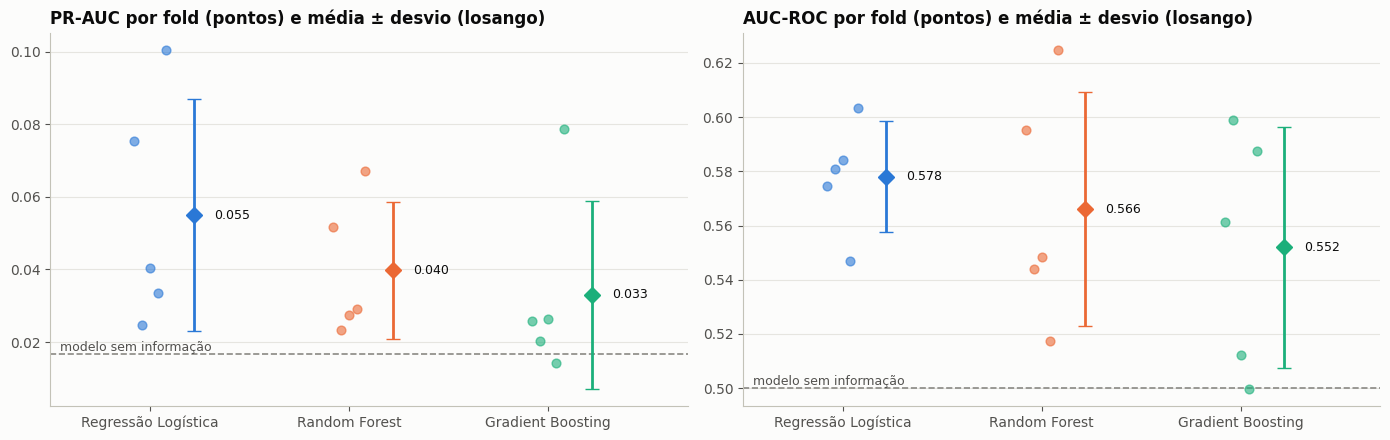

In [8]:
prevalencia = y_train.mean()
nomes = {"regressao_logistica": "Regressão Logística", "random_forest": "Random Forest",
         "gradient_boosting": "Gradient Boosting"}
ordem = list(nomes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (met, base, rot) in zip(axes, [("pr_auc", prevalencia, "PR-AUC"), ("roc_auc", 0.5, "AUC-ROC")]):
    for i, nome in enumerate(ordem):
        v = res.loc[res["modelo"] == nome, met]
        ax.scatter(np.full(len(v), i) + np.linspace(-0.08, 0.08, len(v)), v,
                   color=CORES_MODELOS[i], s=40, alpha=0.6, zorder=3)
        ax.errorbar(i + 0.22, v.mean(), yerr=v.std(), fmt="D", color=CORES_MODELOS[i],
                    markersize=8, capsize=5, linewidth=2, zorder=4)
        ax.text(i + 0.32, v.mean(), f"{v.mean():.3f}", va="center", fontsize=9, color="#0b0b0b")
    ax.axhline(base, color=COR_NEUTRA, linestyle="--", linewidth=1.2)
    ax.text(-0.45, base, "modelo sem informação", va="bottom", ha="left", fontsize=9, color="#52514e")
    ax.set_xticks(range(len(ordem)), [nomes[n] for n in ordem])
    ax.set_xlim(-0.5, len(ordem) - 0.3)
    ax.set_title(f"{rot} por fold (pontos) e média ± desvio (losango)")
    ax.grid(axis="x", visible=False)
fig.tight_layout()
salvar(fig, "03_comparacao_modelos")
plt.show()

**Leitura: qual modelo venceu e por qual margem?**

- **Regressão Logística** tem a maior PR-AUC média (0,055) e a maior AUC-ROC (0,578). Também é a
  **mais estável** em AUC-ROC: desvio de 0,02, contra 0,04 dos modelos de árvore.
- **A diferença está dentro do ruído.** As barras de desvio dos três modelos se sobrepõem, e a
  PR-AUC varia muito de um fold para outro (0,025 a 0,10 na própria logística). Com só ~100 maus
  pagadores por fold, poucos casos bem ou mal ordenados mudam o resultado. Não dá para afirmar que
  um modelo é *estatisticamente* melhor que os outros.
- **Por que isso acontece:** os dados de cadastro carregam pouca informação sobre o pagamento
  futuro. Modelos mais flexíveis (árvores) não têm padrão complexo a explorar. Ganham só
  variância, sem ganho de sinal.

Com empate técnico, o critério de desempate é **simplicidade e explicabilidade**. Isso também
favorece a Regressão Logística: cada atributo tem um peso direto, fácil de auditar e de explicar a
um cliente que teve o crédito negado (LGPD, art. 20).

### 4.1 Atributos selecionados × todos os candidatos

Verificação prometida no notebook 02. A seleção por informação mútua avaliou um atributo por vez.
Aqui comparamos, com os mesmos modelos ajustados, os atributos selecionados contra todos os
candidatos (exceto sexo, excluído por critério ético).

In [9]:
TODAS = [c for c in selecao.index if not selecao.loc[c, "decisao"].startswith(("remover: criterio", "remover: constante", "remover: redundante"))]
NUM_T = [c for c in TODAS if selecao.loc[c, "tipo"] == "numerica"]
CAT_T = [c for c in TODAS if selecao.loc[c, "tipo"] == "categorica"]
print(len(TODAS), "atributos:", TODAS)

modelos_todas = {}
for nome, base in get_models(NUM_T, CAT_T).items():
    params = {k: v for k, v in ajustados[nome].get_params().items() if k.startswith("clf__")}
    modelos_todas[nome] = base.set_params(**params)

res_todas = validar(modelos_todas, treino[TODAS], y_train, g_train, cv)
pd.concat({f"{len(FEATURES)} selecionados": resumo(res)[["pr_auc_mean", "pr_auc_std", "roc_auc_mean", "roc_auc_std"]],
           f"{len(TODAS)} candidatos": resumo(res_todas)[["pr_auc_mean", "pr_auc_std", "roc_auc_mean", "roc_auc_std"]]})

17 atributos: ['cadastro_inconsistente', 'idade_anos', 'FLAG_OWN_REALTY', 'anos_empregado', 'NAME_FAMILY_STATUS', 'AMT_INCOME_TOTAL', 'renda_per_capita', 'OCCUPATION_TYPE', 'NAME_HOUSING_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'CNT_FAM_MEMBERS', 'aposentado_ou_sem_vinculo', 'FLAG_OWN_CAR', 'FLAG_WORK_PHONE', 'FLAG_EMAIL', 'FLAG_PHONE']


pr_auc_mean  pr_auc_std  roc_auc_mean  \
               modelo                                                       
9 selecionados regressao_logistica       0.0549      0.0319        0.5780   
               random_forest             0.0398      0.0189        0.5660   
               gradient_boosting         0.0330      0.0259        0.5520   
17 candidatos  regressao_logistica       0.0534      0.0295        0.5788   
               random_forest             0.0482      0.0161        0.5739   
               gradient_boosting         0.0283      0.0106        0.5504   

                                    roc_auc_std  
               modelo                            
9 selecionados regressao_logistica       0.0205  
               random_forest             0.0432  
               gradient_boosting         0.0444  
17 candidatos  regressao_logistica       0.0127  
               random_forest             0.0453  
               gradient_boosting         0.0501

**Leitura:** a seleção de atributos se sustenta.

- Com os 9 atributos selecionados, a Regressão Logística tem PR-AUC de 0,055 e AUC-ROC de 0,578.
  Com os 17 candidatos, 0,053 e 0,579: **resultado equivalente com quase metade das variáveis**.
- O Random Forest melhora um pouco com 17 atributos (0,040 → 0,048), mas dentro do desvio
  (± 0,02). O Gradient Boosting piora levemente.
- Na rodada anterior, a lista selecionada perdia para a completa. Foi essa diferença que revelou
  o grupo `cadastro_inconsistente` (notebook 02, seção 4.1). Com a nova variável, o modelo
  enxuto recupera todo o sinal.

### 4.2 Por que a validação agrupada importa

Para dimensionar o vazamento, repetimos a validação do Random Forest ajustado com um
`StratifiedKFold` comum, sem grupos. É o que aconteceria seguindo o template ao pé da letra.

In [10]:
cv_comum = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
rf = ajustados["random_forest"]
comum = cross_validate(rf, X_train, y_train, cv=cv_comum, scoring=METRICAS_CV, n_jobs=-1)
agrupada = res[res["modelo"] == "random_forest"]

vazamento = pd.DataFrame({
    "CV comum (com vazamento)": {m: comum[f"test_{m}"].mean() for m in METRICAS_CV},
    "CV agrupada (honesta)": agrupada[list(METRICAS_CV)].mean(),
}).round(3)
vazamento

,CV comum (com vazamento),CV agrupada (honesta)
pr_auc,0.189,0.040
roc_auc,0.773,0.566
recall,0.429,0.018
precision,0.191,0.208
f1,0.264,0.032


**Leitura:** com o split comum, o mesmo Random Forest parece **muito** melhor:

| | CV comum | CV agrupada |
|---|---|---|
| AUC-ROC | 0,77 | 0,57 |
| PR-AUC | 0,19 | 0,04 |

Essa diferença é **ilusória**. O modelo reconhece no teste perfis que já viu no treino (o mesmo
cliente com outro ID) e "lembra" o rótulo. Em produção, os solicitantes são novos, e o desempenho
real seria o da coluna da direita. **Reportar 0,77 seria vender ao negócio um modelo que não
existe.**

## 5. Modelo escolhido e treino final

In [11]:
escolhido = tabela_cv.index[0]
print("Modelo escolhido (maior PR-AUC média na validação cruzada):", escolhido)

finais_treinados = {nome: clone(m).fit(X_train, y_train) for nome, m in ajustados.items()}

MODELS.mkdir(parents=True, exist_ok=True)
joblib.dump({"modelos": finais_treinados, "escolhido": escolhido, "num": NUM, "cat": CAT},
            MODELS / "modelos.joblib")

split = pd.DataFrame({"ID": df["ID"], "conjunto": "treino"})
split.loc[split.index[idx_teste], "conjunto"] = "teste"
split.to_csv(DATA_PROCESSED / "split.csv", index=False)
split["conjunto"].value_counts()

Modelo escolhido (maior PR-AUC média na validação cruzada): regressao_logistica


conjunto
treino    29103
teste      7354
Name: count, dtype: int64

**Modelo escolhido: Regressão Logística** (`C=0,01`, `class_weight="balanced"`, atributos
padronizados), pelos motivos acima:

- maior PR-AUC média;
- maior e mais estável AUC-ROC;
- mais simples de explicar e auditar.

Os três modelos ajustados foram treinados no conjunto de treino completo e salvos em
`results/models/modelos.joblib` (não versionado). A divisão treino/teste foi salva em
`data/processed/split.csv`. O notebook 04 avalia os três **no conjunto de teste, usado pela
primeira vez**, e escolhe o ponto de corte de negócio.